In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"


import numpy as np
import matplotlib.pyplot as plt
import torch
import deepxde as dde

torch.set_default_dtype(torch.float64)
dde.config.set_default_float("float64")
dde.config.set_random_seed(42)

# Problem setup (FAST + SUFFICIENT)
BOX_MIN, BOX_MAX = -3.0, 3.0
R = 0.8
a, b = 1.0, 0.5

N_GRID = 81
N_BC = 400
EPOCHS = 4000

# Geometry
def phi_circle(x, y):
    return x**2 + y**2 - R**2

def phi_ellipse(x, y):
    return x**2/a**2 + y**2/b**2 - 1.0

def outer_boundary(x, on_boundary):
    return on_boundary

def naca0012(x):
    t = 0.12
    return 5*t*(0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1036*x**4)


def make_airfoil_boundary(n=5000):
    beta = np.linspace(0, np.pi, n//2)
    x = (1 - np.cos(beta)) / 2

    yt = naca0012(x)

    # Upper surface
    xu = x - 0.5
    yu = yt

    # Lower surface
    xl = x - 0.5
    yl = -yt

    xb = np.concatenate([xu, xl[::-1]])
    yb = np.concatenate([yu, yl[::-1]])

    return np.column_stack((xb, yb))



def phi_airfoil(x, y):
    pts = make_airfoil_boundary(800)
    
    # 1. Calculate true Euclidean distance (notice the np.sqrt)
    dist = np.min(np.sqrt((x[...,None]-pts[:,0])**2 + (y[...,None]-pts[:,1])**2), axis=-1)
    
    # 2. Determine if points are INSIDE to apply a negative sign
    x_mapped = x + 0.5  # Shift x back to [0, 1] range for the NACA formula
    
    # Use np.clip to prevent passing negative values to np.sqrt inside naca0012
    x_safe = np.clip(x_mapped, 0.0, 1.0)
    yt = naca0012(x_safe)
    
    # A point is inside if it sits within the x-bounds and under the thickness curve
    is_inside = (x_mapped >= 0.0) & (x_mapped <= 1.0) & (np.abs(y) <= yt)
    
    # Return true Signed Distance Function (negative inside, positive outside)
    return np.where(is_inside, -dist, dist)

# Training points
def make_domain_points(phi, n_grid=N_GRID):
    x = np.linspace(BOX_MIN, BOX_MAX, n_grid)
    y = np.linspace(BOX_MIN, BOX_MAX, n_grid)
    X, Y = np.meshgrid(x, y)
    mask = phi(X, Y) > 1e-6
    return np.column_stack((X[mask], Y[mask]))

def make_circle_boundary(n=N_BC):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.column_stack((R*np.cos(t), R*np.sin(t)))

def make_ellipse_boundary(n=N_BC):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    r = 1/np.sqrt((np.cos(t)**2)/a**2 + (np.sin(t)**2)/b**2)
    return np.column_stack((r*np.cos(t), r*np.sin(t)))

# Eikonal PDE
def eikonal_pde(x, d):
    dx = dde.grad.jacobian(d, x, i=0, j=0)
    dy = dde.grad.jacobian(d, x, i=0, j=1)
    return [torch.sqrt(dx**2 + dy**2 + 1e-8) - 1.0, torch.relu(-d)]

Set the default float type to float64


In [76]:
def build_and_train(domain_pts, boundary_pts):
    geom = dde.geometry.Rectangle([BOX_MIN, BOX_MIN], [BOX_MAX, BOX_MAX])

    # Inner boundary (ellipse or circle)
    bc_inner = dde.icbc.PointSetBC(
        boundary_pts,
        np.zeros((len(boundary_pts), 1))
    )

    # Outer boundary (domain edges)
    bc_outer = dde.icbc.DirichletBC(
        geom,
        lambda x: np.sqrt(x[:, 0:1]**2 + x[:, 1:2]**2),
        outer_boundary
    )

    # PDE setup
    data = dde.data.PDE(
        geom,
        eikonal_pde,
        [bc_inner, bc_outer],
        anchors=domain_pts
    )
    net = dde.nn.FNN([2, 64, 64, 64, 1], "tanh", "Glorot uniform")
    model = dde.Model(data, net)

    # Only Adam (FAST + enough)
    model.compile("adam", lr=1e-3, loss_weights=[1.0, 0.1, 25.0, 1.0])
    model.train(epochs=EPOCHS, display_every=500)

    return model

Training Circle...
Compiling model...
'compile' took 0.000139 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [5.80e-01, 1.29e-02, 1.18e+00, 1.24e+01]    [5.80e-01, 1.29e-02, 1.18e+00, 1.24e+01]    []  
500       [8.57e-02, 0.00e+00, 4.68e-04, 1.27e-02]    [8.57e-02, 0.00e+00, 4.68e-04, 1.27e-02]    []  
1000      [7.49e-02, 1.91e-08, 6.92e-03, 1.46e-02]    [7.49e-02, 1.91e-08, 6.92e-03, 1.46e-02]    []  
1500      [6.96e-02, 0.00e+00, 6.88e-04, 1.03e-02]    [6.96e-02, 0.00e+00, 6.88e-04, 1.03e-02]    []  
2000      [6.66e-02, 0.00e+00, 5.46e-04, 9.77e-03]    [6.66e-02, 0.00e+00, 5.46e-04, 9.77e-03]    []  
2500      [6.47e-02, 0.00e+00, 4.15e-04, 9.30e-03]    [6.47e-02, 0.00e+00, 4.15e-04, 9.30e-03]    []  
3000      [6.38e-02, 0.00e+00, 3.61e-04, 9.04e-03]    [6.38e-02, 0.00e+00, 3.61e-04, 9.04e-03]    []  
3500      [6.34e-02, 0.00e+00, 3.46e-04, 8.91e-03]    [6.34e-02, 0.00e+00, 3.46e-04, 

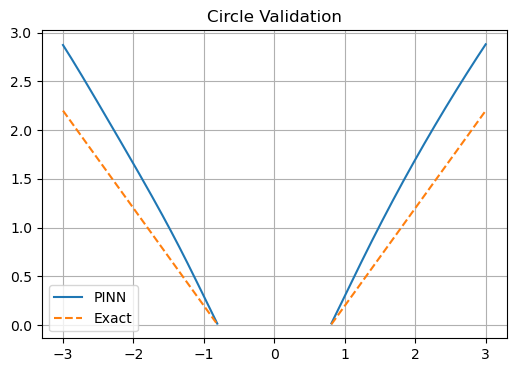

In [77]:
# Grid for plotting
x = np.linspace(BOX_MIN, BOX_MAX, 201)
y = np.linspace(BOX_MIN, BOX_MAX, 201)
X, Y = np.meshgrid(x, y)
XY = np.column_stack((X.ravel(), Y.ravel()))

def predict(model):
    return model.predict(XY).reshape(X.shape)

def mask(field, phi):
    return np.where(phi(X, Y) <= 5e-3, np.nan, field)

# Circle
print("Training Circle...")
circle_model = build_and_train(
    make_domain_points(phi_circle),
    make_circle_boundary()
)

c_pred = mask(predict(circle_model), phi_circle)
c_exact = mask(np.sqrt(X**2 + Y**2) - R, phi_circle)

plt.figure(figsize=(6,4))
plt.plot(x, c_pred[len(y)//2], label="PINN")
plt.plot(x, c_exact[len(y)//2], "--", label="Exact")
plt.title("Circle Validation")
plt.legend()
plt.grid()
plt.show()

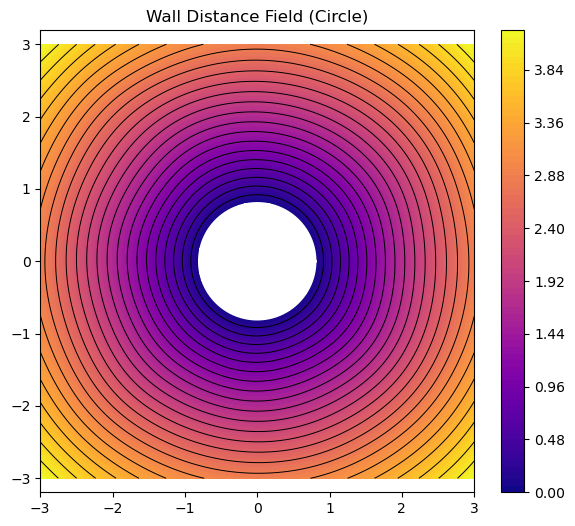

In [78]:
# Circle Contour Plot
levels_c = np.linspace(0, np.nanmax(c_pred), 25)

plt.figure(figsize=(7,6))
cf = plt.contourf(X, Y, c_pred, levels=80, cmap="plasma")
plt.contour(X, Y, c_pred, levels=levels_c, colors="k", linewidths=0.7)

# draw circle boundary
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R*np.cos(theta), R*np.sin(theta), "white", linewidth=2)

plt.title("Wall Distance Field (Circle)")
plt.axis("equal")
plt.colorbar(cf)
plt.show()

Training Ellipse...
Compiling model...
'compile' took 0.000111 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [6.98e-01, 5.44e-03, 5.09e-01, 1.22e+01]    [6.98e-01, 5.44e-03, 5.09e-01, 1.22e+01]    []  
500       [8.21e-02, 5.29e-10, 3.29e-03, 1.46e-02]    [8.21e-02, 5.29e-10, 3.29e-03, 1.46e-02]    []  
1000      [6.40e-02, 0.00e+00, 1.91e-03, 1.01e-02]    [6.40e-02, 0.00e+00, 1.91e-03, 1.01e-02]    []  
1500      [6.05e-02, 0.00e+00, 1.05e-03, 9.23e-03]    [6.05e-02, 0.00e+00, 1.05e-03, 9.23e-03]    []  
2000      [5.90e-02, 0.00e+00, 7.77e-04, 8.72e-03]    [5.90e-02, 0.00e+00, 7.77e-04, 8.72e-03]    []  
2500      [5.81e-02, 0.00e+00, 7.25e-04, 8.40e-03]    [5.81e-02, 0.00e+00, 7.25e-04, 8.40e-03]    []  
3000      [5.79e-02, 1.18e-08, 4.91e-03, 1.11e-02]    [5.79e-02, 1.18e-08, 4.91e-03, 1.11e-02]    []  
3500      [5.71e-02, 0.00e+00, 6.89e-04, 8.00e-03]    [5.71e-02, 0.00e+00, 6.89e-04,

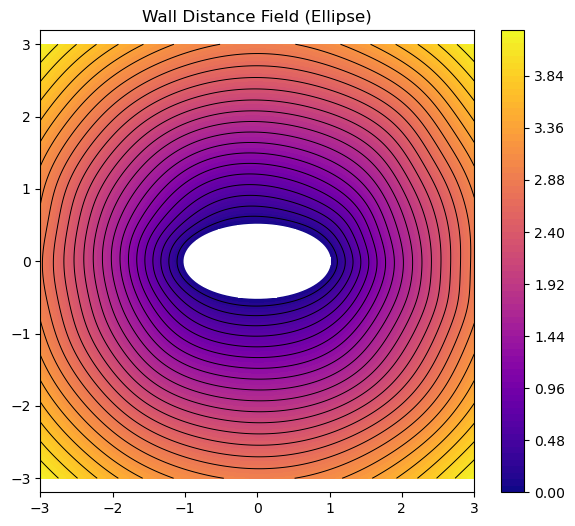

In [79]:
# Ellipse
print("Training Ellipse...")
ellipse_model = build_and_train(
    make_domain_points(phi_ellipse),
    make_ellipse_boundary()
)

e_pred = mask(predict(ellipse_model), phi_ellipse)

levels = np.linspace(0, np.nanmax(e_pred), 25)

plt.figure(figsize=(7,6))
cf = plt.contourf(X, Y, e_pred, levels=80, cmap="plasma")
plt.contour(X, Y, e_pred, levels=levels, colors="k", linewidths=0.7)
plt.plot(*make_ellipse_boundary().T, "white", linewidth=2)

plt.title("Wall Distance Field (Ellipse)")
plt.axis("equal")
plt.colorbar(cf)
plt.show()

Training Airfoil...
Compiling model...
'compile' took 0.000168 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.71e-01, 1.73e-02, 1.20e-02, 1.25e+01]    [4.71e-01, 1.73e-02, 1.20e-02, 1.25e+01]    []  
500       [5.15e-02, 8.15e-07, 3.80e-02, 8.26e-03]    [5.15e-02, 8.15e-07, 3.80e-02, 8.26e-03]    []  
1000      [3.47e-02, 2.86e-07, 3.09e-02, 6.32e-03]    [3.47e-02, 2.86e-07, 3.09e-02, 6.32e-03]    []  
1500      [2.66e-02, 1.52e-07, 2.31e-02, 5.03e-03]    [2.66e-02, 1.52e-07, 2.31e-02, 5.03e-03]    []  
2000      [1.93e-02, 2.87e-09, 2.08e-03, 2.11e-03]    [1.93e-02, 2.87e-09, 2.08e-03, 2.11e-03]    []  
2500      [1.54e-02, 1.56e-09, 2.36e-03, 1.49e-03]    [1.54e-02, 1.56e-09, 2.36e-03, 1.49e-03]    []  
3000      [1.41e-02, 2.52e-10, 2.23e-03, 1.26e-03]    [1.41e-02, 2.52e-10, 2.23e-03, 1.26e-03]    []  
3500      [1.32e-02, 4.18e-11, 2.06e-03, 1.16e-03]    [1.32e-02, 4.18e-11, 2.06e-03,

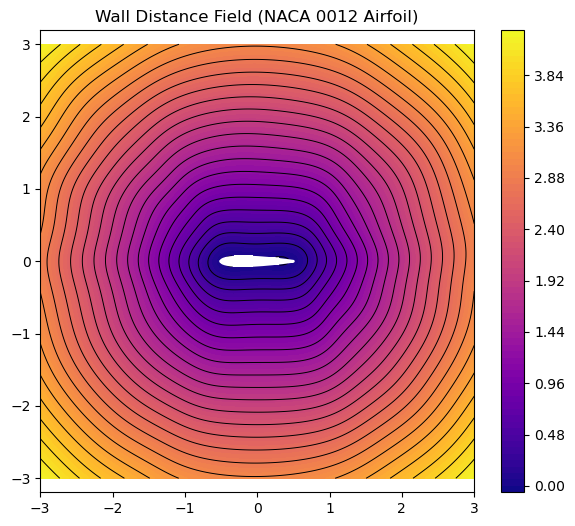

In [ ]:
-